# Inspeção Visual de Peças de Fundição Metálica

Mini-projeto de visão computacional + CNN para classificação binária de peças fundidas
(**OK** vs **Defeituosa**), usando o dataset *Casting Product Image Data for Quality Inspection*.

O fluxo segue seis sprints industriais: ingestão → OpenCV clássico → morfologia →
pipeline Keras → CNN → auditoria de performance.

## Sprint 1 — Configuração e ingestão dos dados

Objetivo: ambiente reprodutível e dataset acessível localmente em `casting_data/`
(`def_front/` e `ok_front/`). Sem seed fixa, qualquer comparação entre execuções
(treino, split, augmentation) fica inválida em auditoria.

In [1]:
from pathlib import Path
import random
import zipfile

import numpy as np
import tensorflow as tf

# Mesma seed em NumPy, Python e TF: o split 80/20 e o shuffle do dataset
# precisam coincidir entre notebooks do time e entre reexecuções na fábrica.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Determinismo "melhor esforço" no TF (não elimina 100% da variação em GPU,
# mas reduz ruído na comparação de hiperparâmetros).
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print(f"TensorFlow {tf.__version__} | seed={SEED}")

TensorFlow 2.19.1 | seed=42


In [2]:
# Caminhos do projeto
ROOT = Path(".").resolve()
DATA_DIR = ROOT / "casting_data"
DRIVE_FILE_ID = "1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK"
ZIP_PATH = ROOT / "casting_dataset.zip"


def contar_imagens(pasta: Path) -> int:
    return sum(1 for p in pasta.rglob("*") if p.suffix.lower() in {".jpeg", ".jpg", ".png"})


def dataset_pronto(data_dir: Path) -> bool:
    """Exige as duas classes com pelo menos uma imagem cada (ignora .gitkeep vazio)."""
    d_def, d_ok = data_dir / "def_front", data_dir / "ok_front"
    return (
        d_def.is_dir()
        and d_ok.is_dir()
        and contar_imagens(d_def) > 0
        and contar_imagens(d_ok) > 0
    )


def baixar_dataset_drive(file_id: str, destino_zip: Path) -> None:
    # gdown trata a confirmação de download grande do Drive; requests puro falha com HTML de aviso.
    import gdown

    url = f"https://drive.google.com/uc?id={file_id}"
    print("Baixando dataset do Google Drive...")
    gdown.download(url, str(destino_zip), quiet=False)


def extrair_e_normalizar(zip_path: Path, data_dir: Path) -> None:
    """Extrai o zip e acomoda pastas caso o arquivo venha com um nível extra de diretório."""
    data_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_dir)

    # Alguns dumps trazem casting_data/casting_data/... — sobe um nível se necessário.
    nested = data_dir / "casting_data"
    if nested.is_dir() and not dataset_pronto(data_dir):
        for item in nested.iterdir():
            alvo = data_dir / item.name
            if not alvo.exists():
                item.rename(alvo)

    # Caso as classes estejam na raiz do projeto (legado), move para casting_data/
    for classe in ("def_front", "ok_front"):
        origem = ROOT / classe
        destino = data_dir / classe
        if origem.is_dir() and not destino.exists():
            origem.rename(destino)


if dataset_pronto(DATA_DIR):
    print(f"Dataset local encontrado em: {DATA_DIR}")
else:
    if not ZIP_PATH.exists():
        baixar_dataset_drive(DRIVE_FILE_ID, ZIP_PATH)
    extrair_e_normalizar(ZIP_PATH, DATA_DIR)
    if not dataset_pronto(DATA_DIR):
        raise FileNotFoundError(
            "Após o download, não achei def_front/ e ok_front/ em casting_data/. "
            "Confira a estrutura do arquivo do Drive."
        )
    print(f"Dataset preparado em: {DATA_DIR}")

n_def = contar_imagens(DATA_DIR / "def_front")
n_ok = contar_imagens(DATA_DIR / "ok_front")
print(f"Classes | def_front={n_def} | ok_front={n_ok} | total={n_def + n_ok}")
print(
    "Desbalanceamento leve é esperado neste dataset; a métrica accuracy "
    "sozinha pode mascarar falhas na classe minoritária — por isso olhamos as curvas na Sprint 6."
)

Dataset local encontrado em: C:\Users\Teco\Desktop\Mini_projeto_M2\casting_data
Classes | def_front=781 | ok_front=519 | total=1300
Desbalanceamento leve é esperado neste dataset; a métrica accuracy sozinha pode mascarar falhas na classe minoritária — por isso olhamos as curvas na Sprint 6.


## Sprint 2 — EDA clássica (OpenCV: filtros e ruído)

Antes da CNN, inspecionamos o sinal ótico real da esteira: iluminação irregular,
textura do metal e ruído de sensor. Filtros lineares vs. de ordem mostram que tipo
de ruído domina e se ainda precisamos de morfologia na Sprint 3.

In [3]:
import cv2
import matplotlib.pyplot as plt

def carregar_amostra(pasta: Path, indice: int = 0) -> tuple[np.ndarray, Path]:
    arquivos = sorted(pasta.glob("*.jpeg")) + sorted(pasta.glob("*.jpg"))
    if not arquivos:
        raise FileNotFoundError(f"Nenhuma imagem em {pasta}")
    caminho = arquivos[indice % len(arquivos)]
    # IMREAD_COLOR mantém BGR (padrão OpenCV). Converter cedo demais para RGB
    # só importa na hora de plotar com matplotlib.
    bgr = cv2.imread(str(caminho), cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError(f"Falha ao ler {caminho}")
    return bgr, caminho


bgr_def, path_def = carregar_amostra(DATA_DIR / "def_front", indice=0)
bgr_ok, path_ok = carregar_amostra(DATA_DIR / "ok_front", indice=0)

gray_def = cv2.cvtColor(bgr_def, cv2.COLOR_BGR2GRAY)
gray_ok = cv2.cvtColor(bgr_ok, cv2.COLOR_BGR2GRAY)

# GaussianBlur: convolução com kernel gaussiano — ideal para ruído aproximadamente
# aditivo/gaussiano (sensor). Suaviza também bordas finas; por isso o kernel fica modesto (5x5).
gauss_def = cv2.GaussianBlur(gray_def, (5, 5), sigmaX=1.2)
gauss_ok = cv2.GaussianBlur(gray_ok, (5, 5), sigmaX=1.2)

# medianBlur: cada pixel vira a mediana da vizinhança. Impulsos (sal e pimenta)
# são outliers e somem sem "espalhar" a mancha como a média/gaussiana faria.
# Em fundição, sujeira pontual no sensor/óleo na lente se comporta parecido com salt-pepper.
median_def = cv2.medianBlur(gray_def, 5)
median_ok = cv2.medianBlur(gray_ok, 5)

print("Amostra defeituosa:", path_def.name, gray_def.shape)
print("Amostra OK:", path_ok.name, gray_ok.shape)

Amostra defeituosa: cast_def_0_0.jpeg (512, 512)
Amostra OK: cast_ok_0_1018.jpeg (512, 512)


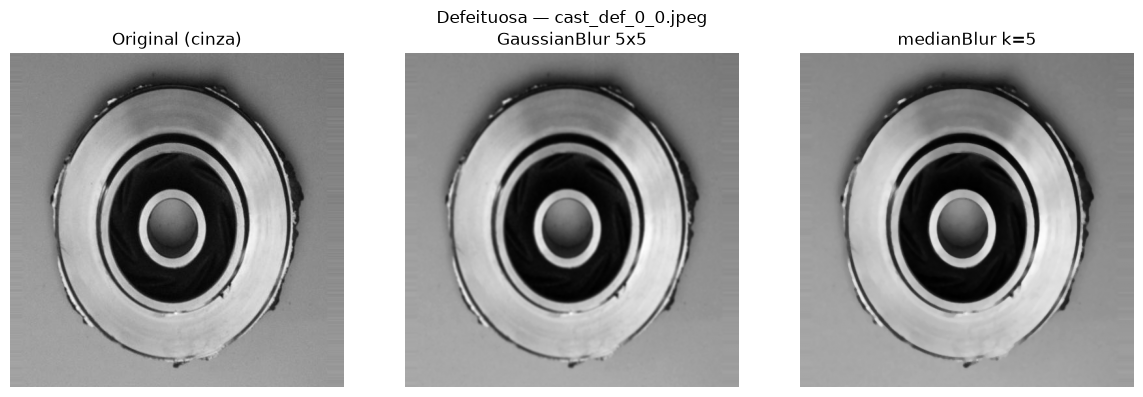

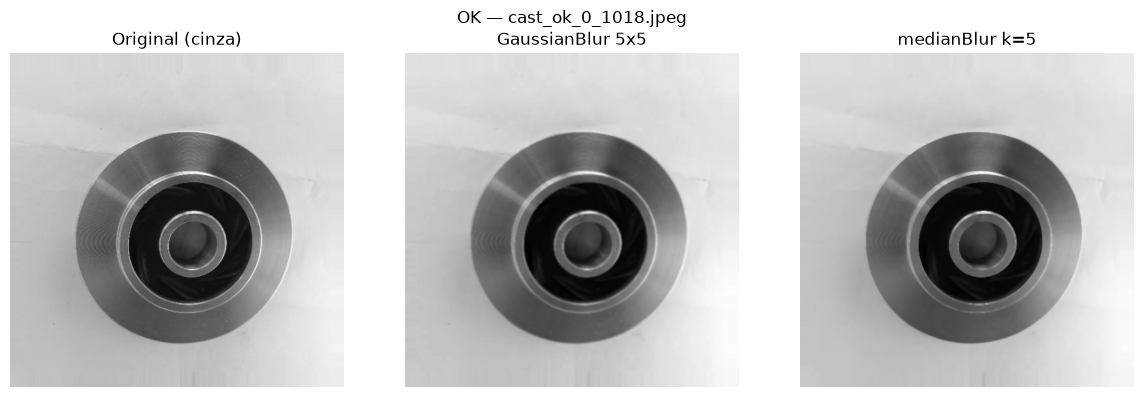

Leitura prática: se pontos brancos/pretos isolados somem no median e permanecem no gaussiano, o ruído dominante é impulsivo. Se o fundo 'enevoa' igual nos dois, é mais ruído de alta frequência / textura — aí Canny na Sprint 3 precisa de blur prévio.


In [4]:
def painel_filtros(titulo: str, gray, gauss, median):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    painéis = [
        (gray, "Original (cinza)"),
        (gauss, "GaussianBlur 5x5"),
        (median, "medianBlur k=5"),
    ]
    for ax, (img, label) in zip(axes, painéis):
        ax.imshow(img, cmap="gray")
        ax.set_title(label)
        ax.axis("off")
    fig.suptitle(titulo)
    fig.tight_layout()
    plt.show()


painel_filtros(f"Defeituosa — {path_def.name}", gray_def, gauss_def, median_def)
painel_filtros(f"OK — {path_ok.name}", gray_ok, gauss_ok, median_ok)

print(
    "Leitura prática: se pontos brancos/pretos isolados somem no median e permanecem "
    "no gaussiano, o ruído dominante é impulsivo. Se o fundo 'enevoa' igual nos dois, "
    "é mais ruído de alta frequência / textura — aí Canny na Sprint 3 precisa de blur prévio."
)

## Sprint 3 — Bordas e morfologia (isolamento de defeito)

Limiar fixo quebra com mudança de luz na linha. **Otsu** escolhe o limiar que
minimiza a variância intra-classe do histograma — adequado quando há dois modos
(peça vs. fundo/defeito). Canny + morfologia transformam a ranhura/trinca em
componente conectado auditável visualmente.

In [5]:
# Trabalhamos sobre a mediana: menos falsos edges por impulsos na hora do Canny.
base = median_def

# THRESH_OTSU ignora o valor limiar passado (0) e calcula automaticamente.
# BINARY_INV: em muitas peças o defeito é região escura — invertemos para o
# "objeto" (defeito) ficar branco (255), padrão das operações morfológicas.
otsu_val, mask_otsu = cv2.threshold(
    base, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Canny: gradiente + histerese. Limiares ~1:2 ou 1:3 reduzem bordas fracas de textura.
# Como a imagem já foi suavizada, podemos usar valores moderados sem pré-blur extra.
edges = cv2.Canny(base, threshold1=50, threshold2=150)

# Elemento estruturante elíptico acompanha melhor cavidades/curvas do que um quadrado.
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Abertura (erosão → dilatação): remove pontos brancos menores que o kernel
# (ruído na máscara) e preserva a ranhura se ela for maior que o elemento.
mask_open = cv2.morphologyEx(mask_otsu, cv2.MORPH_OPEN, kernel, iterations=1)

# Fechamento (dilatação → erosão): preenche buracos internos na trinca e une
# segmentos quebrados da mesma falha — útil quando o defeito aparece "tracejado".
mask_close = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel, iterations=2)

print(f"Limiar Otsu escolhido: {otsu_val:.1f}")

Limiar Otsu escolhido: 95.0


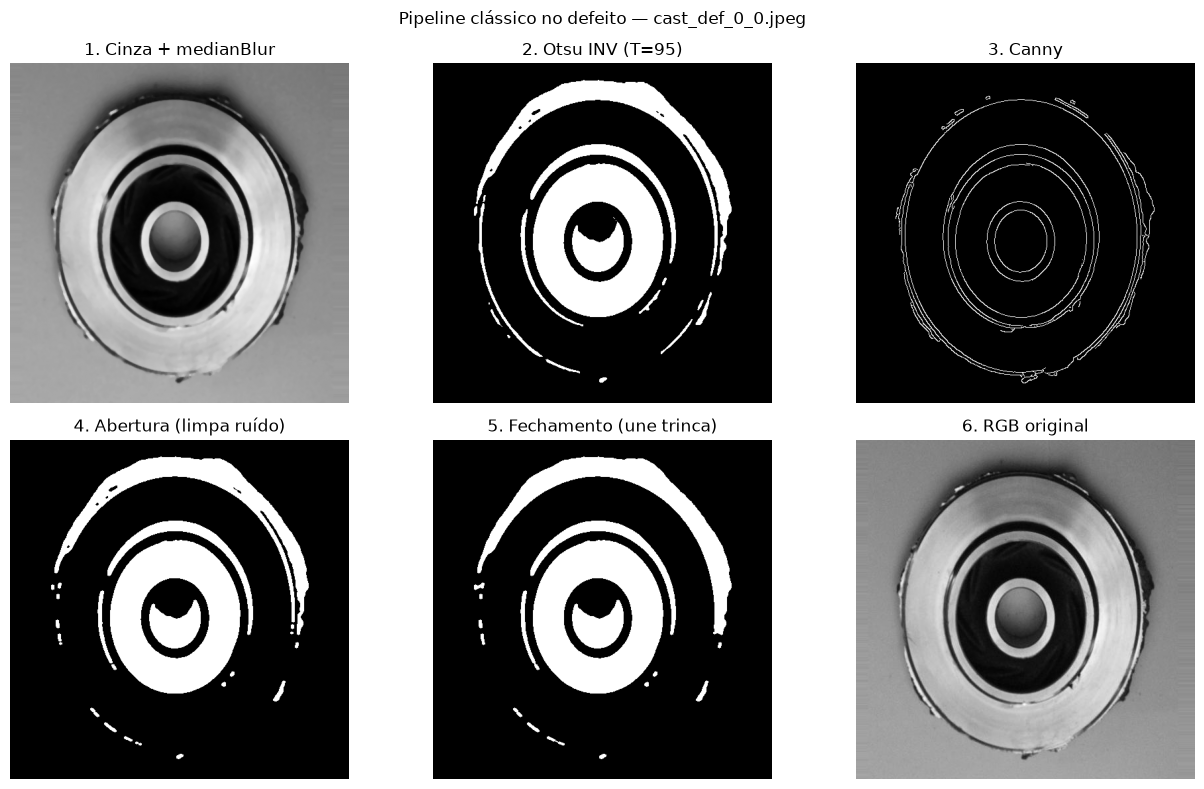

Interpretação: a máscara final não substitui a CNN — ela valida se o defeito é geometricamente separável. Se mesmo após fechamento a falha some, o caso depende de textura/contexto e justifica o modelo aprendido nas Sprints 4–5.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
etapas = [
    (base, "1. Cinza + medianBlur"),
    (mask_otsu, f"2. Otsu INV (T={otsu_val:.0f})"),
    (edges, "3. Canny"),
    (mask_open, "4. Abertura (limpa ruído)"),
    (mask_close, "5. Fechamento (une trinca)"),
    (cv2.cvtColor(bgr_def, cv2.COLOR_BGR2RGB), "6. RGB original"),
]
for ax, (img, titulo) in zip(axes.ravel(), etapas):
    if img.ndim == 2:
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)
    ax.set_title(titulo)
    ax.axis("off")
fig.suptitle(f"Pipeline clássico no defeito — {path_def.name}")
fig.tight_layout()
plt.show()

print(
    "Interpretação: a máscara final não substitui a CNN — ela valida se o defeito "
    "é geometricamente separável. Se mesmo após fechamento a falha some, o caso "
    "depende de textura/contexto e justifica o modelo aprendido nas Sprints 4–5."
)

## Sprint 4 — Ingestão Keras e Data Augmentation

`image_dataset_from_directory` amarra o rótulo ao nome da pasta — evita CSV frágil.
Augmentation como **camadas** do modelo aplica só no treino em graph mode (mais
portável para exportação do que `ImageDataGenerator`, legado).

In [7]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
# validation_split + subset exige seed igual para treino/val não vazarem amostras.
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",  # sigmoid na saída: um logit por imagem
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,  # validação estável para curvas comparáveis entre épocas
)

class_names = train_ds.class_names
print("Ordem das classes (índice → nome):", class_names)
print(
    "Com label_mode=binary, o índice 1 corresponde à segunda classe na ordem "
    f"lexicográfica das pastas. Aqui: 0={class_names[0]}, 1={class_names[1]}."
)

# Flip H+V e rotações/zoom leves simulam peça girada na esteira e variação de
# enquadramento da câmera fixa — sem inventar defeitos novos (evitamos elastic
# warp agressivo que criaria artefatos irreais em metal usinado/fundido).
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

# cache: após a 1ª época as imagens já decodificadas ficam em RAM/disco.
# prefetch(AUTOTUNE): enquanto a GPU/CPU treina o batch N, o pipeline prepara N+1.
# Sem prefetch, o treino fica ocioso esperando I/O — gargalo clássico em inspeção
# com JPEG 512px redimensionado para 300px.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

for x_batch, y_batch in train_ds.take(1):
    print("Batch X:", x_batch.shape, "dtype=", x_batch.dtype)
    print("Batch y:", y_batch.shape, "exemplo=", y_batch[:8].numpy().reshape(-1))

Found 1300 files belonging to 2 classes.
Using 1040 files for training.
Found 1300 files belonging to 2 classes.
Using 260 files for validation.
Ordem das classes (índice → nome): ['def_front', 'ok_front']
Com label_mode=binary, o índice 1 corresponde à segunda classe na ordem lexicográfica das pastas. Aqui: 0=def_front, 1=ok_front.
Batch X: (32, 300, 300, 3) dtype= <dtype: 'float32'>
Batch y: (32, 1) exemplo= [1. 1. 0. 0. 0. 0. 1. 1.]


## Sprint 5 — CNN sequencial e treinamento

Três blocos Conv+Pool bastam para este problema de textura local (ranhuras):
campos receptivos crescem sem ir para redes profundas demais no dataset ~1k imagens.
Dropout 0.5 **depois** do Flatten/antes da Dense densa — é ali que há mais
parâmetros e maior risco de memorizar o treino.

In [8]:
# Augmentation + Rescaling dentro do Sequential: no export, o pré-processamento
# viaja com o grafo — o operador na linha manda JPEG uint8 e o modelo normaliza.
# 32 → 64 → 128 filtros: hierarquia borda → padrão → mancha/trinca.
# Dropout 0.5 após a Dense intermediária: é onde há mais parâmetros e o dataset
# (~1k imagens) overfitta fácil se a rede memorizar o mapa achatado.
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=IMG_SIZE + (3,)),
        data_augmentation,
        tf.keras.layers.Rescaling(1.0 / 255.0),
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ],
    name="cnn_fundicao",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    # binary_crossentropy alinha com sigmoid + label float 0/1.
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "cnn_fundicao"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 300, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    22,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,523,201 (85.92 MB)

 Trainable params: 22,523,201 (85.92 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
EPOCHS = 12  # 10–15: suficiente para ver convergência sem treino maratona em CPU

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

# Persistência opcional para auditoria offline (ignorada no git).
model.save("modelo_fundicao.keras")
print("Treino finalizado. Histórico com chaves:", list(history.history.keys()))

Epoch 1/12


c:\Users\Teco\Desktop\Mini_projeto_M2\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


33/33 ━━━━━━━━━━━━━━━━━━━━ 163s 5s/step - accuracy: 0.6154 - loss: 0.9633 - val_accuracy: 0.0000e+00 - val_loss: 0.9574
Epoch 2/12
33/33 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.6779 - loss: 0.6137 - val_accuracy: 0.7038 - val_loss: 0.6801
Epoch 3/12
33/33 ━━━━━━━━━━━━━━━━━━━━ 158s 5s/step - accuracy: 0.7106 - loss: 0.5696 - val_accuracy: 0.7654 - val_loss: 0.6239
Epoch 4/12
33/33 ━━━━━━━━━━━━━━━━━━━━ 132s 4s/step - accuracy: 0.7337 - loss: 0.5487 - val_accuracy: 0.7269 - val_loss: 0.6813
Epoch 5/12
33/33 ━━━━━━━━━━━━━━━━━━━━ 157s 5s/step - accuracy: 0.7279 - loss: 0.5385 - val_accuracy: 0.7385 - val_loss: 0.6551
Epoch 6/12
33/33 ━━━━━━━━━━━━━━━━━━━━ 147s 4s/step - accuracy: 0.7404 - loss: 0.5114 - val_accuracy: 0.6769 - val_loss: 0.6959
Epoch 7/12
33/33 ━━━━━━━━━━━━━━━━━━━━ 169s 5s/step - accuracy: 0.7356 - loss: 0.5060 - val_accuracy: 0.8038 - val_loss: 0.5614
Epoch 8/12
33/33 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.7442 - loss: 0.4863 - val_accuracy: 0.7308 - val_loss

## Sprint 6 — Auditoria de performance

Curvas de loss/accuracy separam **ajuste** de **generalização**. Overfitting típico:
treino sobe/desce bem, validação estagna ou piora. Underfitting: ambos ruins.

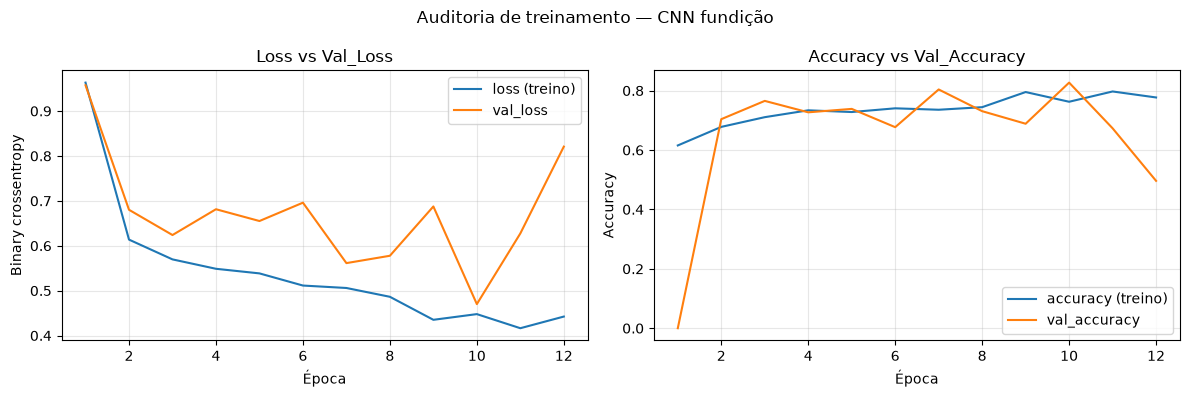

Gap final accuracy (treino - val): 0.2808
Gap final loss (val - treino): 0.3784
Sinais de overfitting: treino claramente à frente da validação e val_loss já não está no mínimo. Próximo passo: mais dropout/augmentation, early stopping ou mais dados da linha.


In [10]:
hist = history.history
epochs_range = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, hist["loss"], label="loss (treino)")
axes[0].plot(epochs_range, hist["val_loss"], label="val_loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Binary crossentropy")
axes[0].set_title("Loss vs Val_Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, hist["accuracy"], label="accuracy (treino)")
axes[1].plot(epochs_range, hist["val_accuracy"], label="val_accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Val_Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("Auditoria de treinamento — CNN fundição")
fig.tight_layout()
plt.show()

final_gap_acc = hist["accuracy"][-1] - hist["val_accuracy"][-1]
final_gap_loss = hist["val_loss"][-1] - hist["loss"][-1]
print(f"Gap final accuracy (treino - val): {final_gap_acc:.4f}")
print(f"Gap final loss (val - treino): {final_gap_loss:.4f}")

# Critério pragmático de chão de fábrica (não é p-value): gap de accuracy > ~0.05
# com val_loss subindo enquanto train_loss cai => overfitting; ambos altos => underfitting.
if final_gap_acc > 0.05 and hist["val_loss"][-1] > min(hist["val_loss"]):
    diagnostico = (
        "Sinais de overfitting: treino claramente à frente da validação e val_loss "
        "já não está no mínimo. Próximo passo: mais dropout/augmentation, early stopping "
        "ou mais dados da linha."
    )
elif hist["accuracy"][-1] < 0.75 and hist["val_accuracy"][-1] < 0.75:
    diagnostico = (
        "Sinais de underfitting: treino e validação ainda fracos. Vale treinar mais "
        "épocas, subir capacidade (filtros) ou revisar qualidade do rótulo/imagens."
    )
else:
    diagnostico = (
        "Curvas coerentes: gaps moderados. Mesmo assim, em produção combine accuracy "
        "com matriz de confusão / recall da classe defeituosa — falso OK é o erro caro."
    )

print(diagnostico)

### Encerramento

Pipeline completo: dados versionados em pastas → diagnóstico OpenCV → dataset
tf.data → CNN com augmentation no grafo → auditoria gráfica. O `README.md` do
repositório descreve ambiente, estrutura e como reproduzir o treino.